# Лабораторная работа № 5

## Решение задачи многомерной регрессии

**Цель работы:** изучение принципов решения задачи многомерной регрессии с использованием методов машинного обучения.

Проанализируем набор данных `hydrocarbon.csv`. Когда бензин закачивается в баки, происходит утечка углеводородов. Для оценки эффективности мер по борьбе с загрязнением окружающей среды были проведены эксперименты. Количество выделяющихся углеводородов было измерено в зависимости от температуры в баке, температуры бензина, закачиваемого в бак, начального давления в баке и давления закачиваемого бензина.

Признаки:
- **temp_tank** – температура в баке
- **temp_fuel** – температура бензина
- **pressure_tank** – начальное давление в баке
- **pressure_fuel** – давление бензина
- **hydrocarbon_leak** – количество выделяющихся углеводородов (в услов. ед.) – целевая переменная

## 0. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
sns.set_style("whitegrid")

## 1. Загрузка набора данных как датафрейма библиотеки pandas

In [2]:
df = pd.read_csv('hydrocarbon.csv')
print("Размер датафрейма:", df.shape)
df.head()

Размер датафрейма: (1000, 5)


,temp_tank,temp_fuel,pressure_tank,pressure_fuel,hydrocarbon_leak
0,21.236204,10.553988,152.341137,318.175749,44.333782
1,38.521429,21.257028,149.395760,349.170349,48.623984
2,31.959818,31.188375,281.250916,212.616975,134.993913
3,27.959755,26.966747,149.909240,306.218525,51.448264
4,14.680559,29.196834,154.389945,292.936496,41.815720


## 2. Общее представление о наборе данных: shape, head, describe, info

In [3]:
df.shape

(1000, 5)

In [4]:
df.head(10)

,temp_tank,temp_fuel,pressure_tank,pressure_fuel,hydrocarbon_leak
0,21.236204,10.553988,152.341137,318.175749,44.333782
1,38.521429,21.257028,149.395760,349.170349,48.623984
2,31.959818,31.188375,281.250916,212.616975,134.993913
3,27.959755,26.966747,149.909240,306.218525,51.448264
4,14.680559,29.196834,154.389945,292.936496,41.815720
5,14.679836,24.763501,251.879652,358.207594,74.998224
6,11.742508,25.768297,189.947968,376.521765,36.022314
7,35.985284,30.475870,255.342111,153.039193,131.235061
8,28.033450,12.490040,113.073232,318.504980,22.059774
9,31.242177,19.682749,197.514239,162.958950,102.854163


In [5]:
df.describe()

,temp_tank,temp_fuel,pressure_tank,pressure_fuel,hydrocarbon_leak
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,24.707697,20.210519,200.481145,272.593762,76.537569
std,8.764121,8.765697,58.134839,71.622336,34.166127
min,10.138961,5.096548,100.002327,150.163348,-11.460609
25%,17.079198,12.232228,152.270195,210.475193,50.338487
50%,24.904221,20.562017,200.122784,271.069821,76.217577
75%,32.329588,27.813952,251.820705,334.385203,102.882214
max,39.991530,34.982412,299.564171,399.889426,163.347934


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   temp_tank         1000 non-null   float64
 1   temp_fuel         1000 non-null   float64
 2   pressure_tank     1000 non-null   float64
 3   pressure_fuel     1000 non-null   float64
 4   hydrocarbon_leak  1000 non-null   float64
dtypes: float64(5)
memory usage: 39.2 KB


## 3. Разведочный анализ данных

Визуализируем распределения признаков и зависимости между ними с помощью библиотек matplotlib и seaborn.

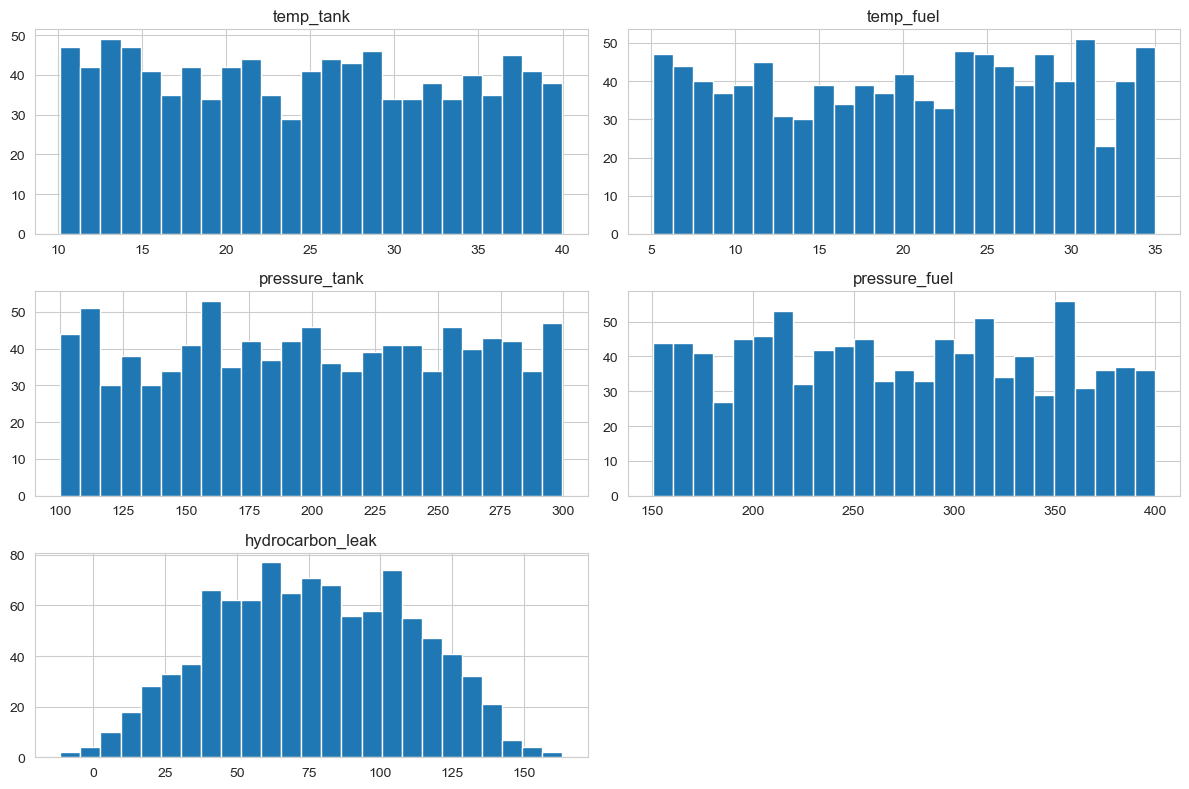

In [7]:
df.hist(figsize=(12, 8), bins=25)
plt.tight_layout()
plt.show()

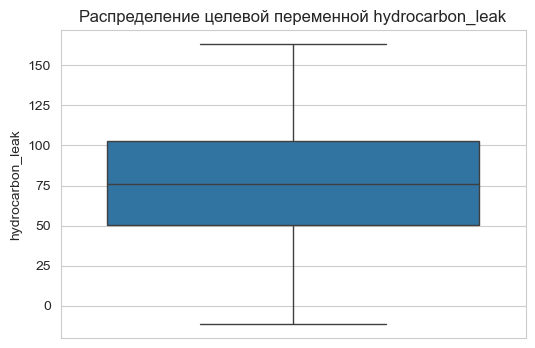

In [8]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['hydrocarbon_leak'])
plt.title('Распределение целевой переменной hydrocarbon_leak')
plt.show()

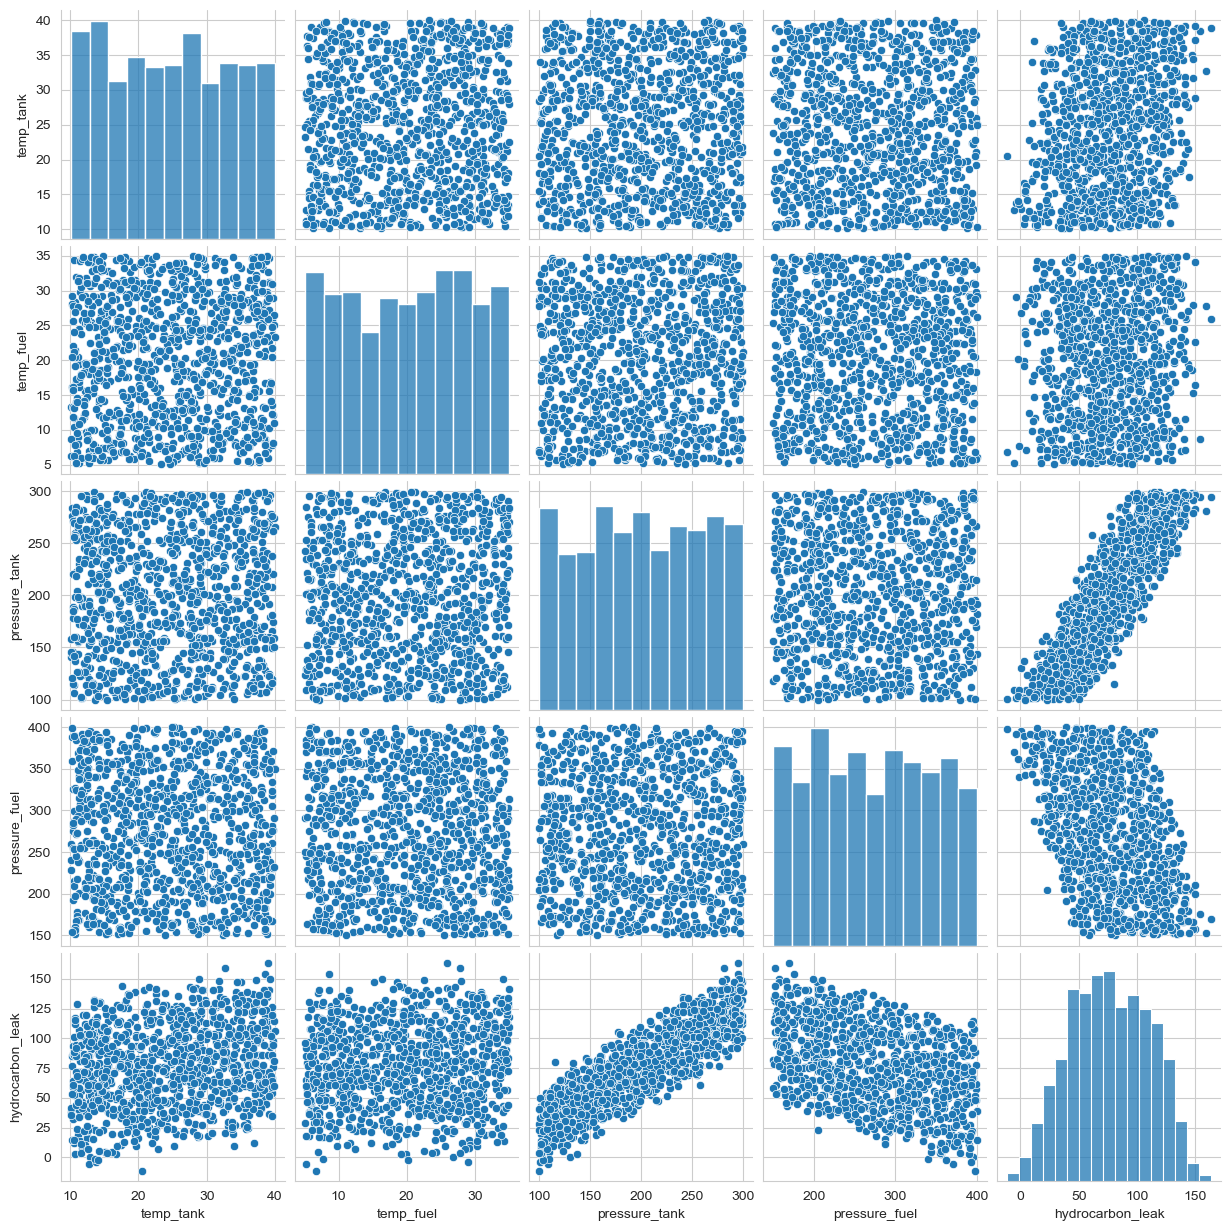

In [9]:
sns.pairplot(df)
plt.show()

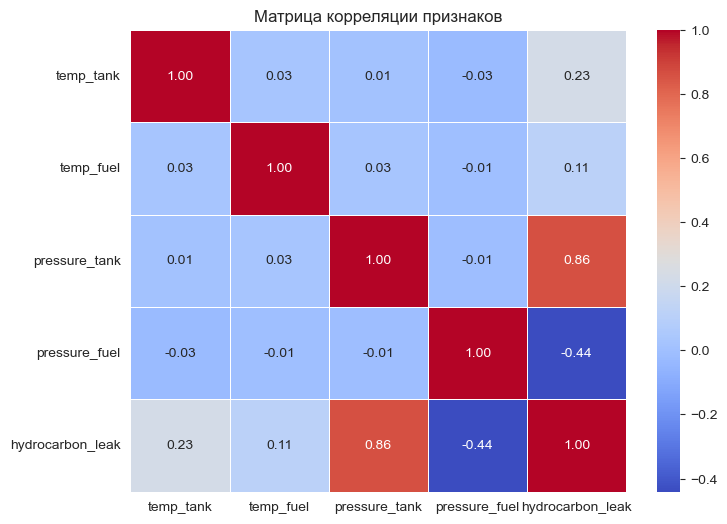

In [10]:
plt.figure(figsize=(8, 6))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции признаков')
plt.show()

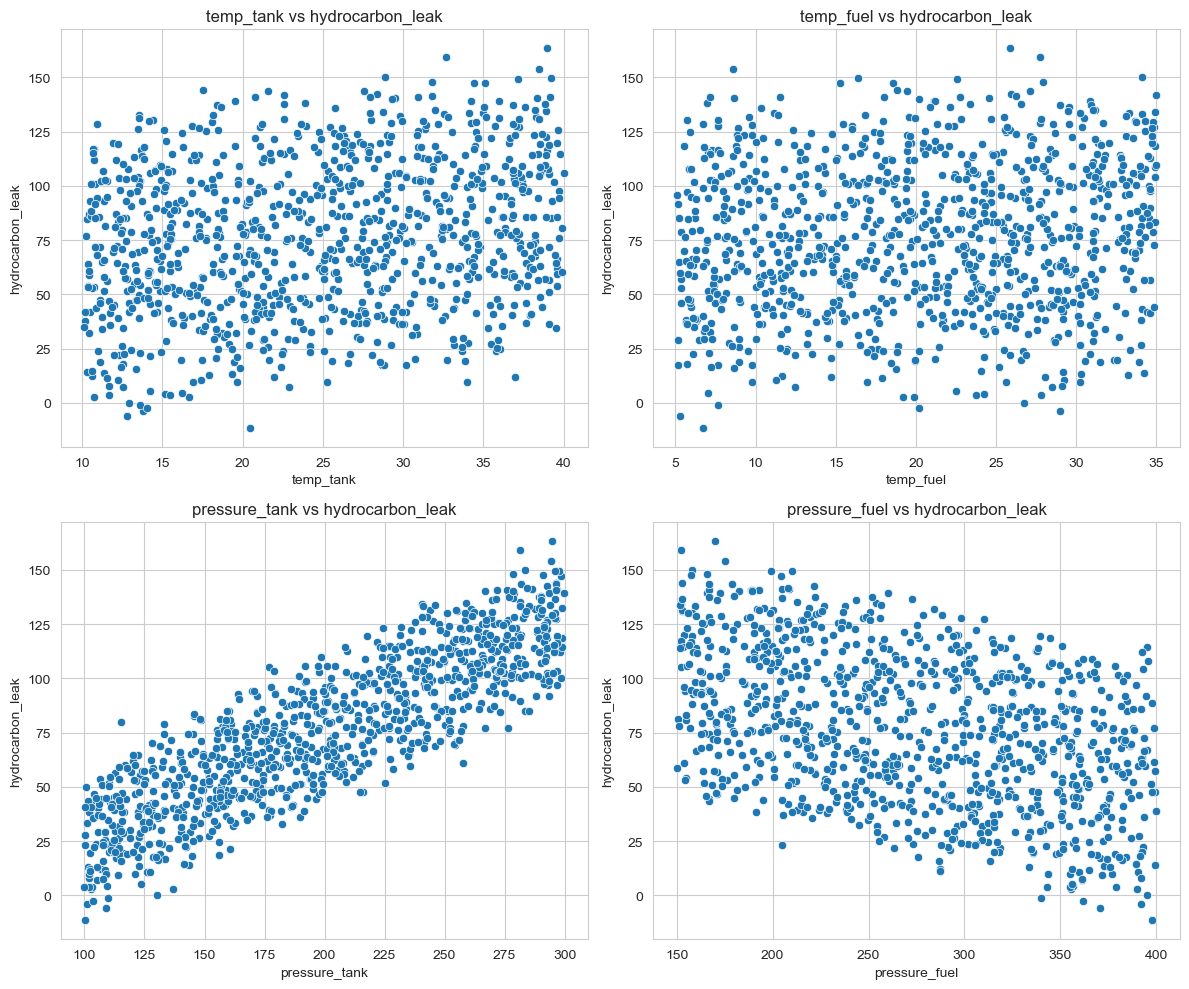

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = ['temp_tank', 'temp_fuel', 'pressure_tank', 'pressure_fuel']
for ax, col in zip(axes.flatten(), features):
    sns.scatterplot(data=df, x=col, y='hydrocarbon_leak', ax=ax)
    ax.set_title(f'{col} vs hydrocarbon_leak')
plt.tight_layout()
plt.show()

## 4. Влияние признаков на целевую переменную

По матрице корреляции и диаграммам рассеяния видно, что все четыре признака (`temp_tank`, `temp_fuel`, `pressure_tank`, `pressure_fuel`) демонстрируют заметную положительную связь с целевой переменной `hydrocarbon_leak`. Несущественных признаков, которые следовало бы удалить из набора, не обнаружено – все признаки являются информативными и сохраняются для построения модели регрессии.

## 5. Предобработка данных

### 5.1. Проверка пропущенных значений

In [12]:
df.isna().sum()

temp_tank           0
temp_fuel           0
pressure_tank       0
pressure_fuel       0
hydrocarbon_leak    0
dtype: int64

Пропущенных значений в наборе данных нет, поэтому дополнительная обработка не требуется.

### 5.2. Кодирование категориальных признаков

Все признаки набора данных `hydrocarbon.csv` являются числовыми, категориальных признаков нет, поэтому кодирование не требуется.

### 5.3. Нормализация данных с помощью методов библиотеки sklearn

In [13]:
feature_cols = ['temp_tank', 'temp_fuel', 'pressure_tank', 'pressure_fuel']
X = df[feature_cols]
y = df['hydrocarbon_leak']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)
X_scaled.head()

,temp_tank,temp_fuel,pressure_tank,pressure_fuel
0,-0.396301,-1.102179,-0.828489,0.636740
1,1.576957,0.119447,-0.879179,1.069707
2,0.827893,1.252992,1.390047,-0.837822
3,0.371251,0.771143,-0.870342,0.469708
4,-1.144685,1.025681,-0.793229,0.284170


## 6. Разбиение обработанного набора данных на обучающую и тестовую выборки

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=0)
print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (750, 4)
Размер тестовой выборки: (250, 4)


## 7. Обучение модели линейной регрессии (LinearRegression) библиотеки sklearn

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

coef_df = pd.DataFrame({'feature': feature_cols, 'coefficient': model.coef_})
print("Свободный член (intercept):", model.intercept_)
coef_df

Свободный член (intercept): 76.45007605186036


,feature,coefficient
0,temp_tank,6.700533
1,temp_fuel,2.760384
2,pressure_tank,28.990396
3,pressure_fuel,-14.477424


## 8. Оценка корректности модели на тестовой и обучающей выборках

Используем стандартные метрики библиотеки sklearn: MAE, MSE, RMSE, R².

In [16]:
def print_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)
    print()

print_metrics(y_train, y_train_pred, "Обучающая выборка")
print_metrics(y_test, y_test_pred, "Тестовая выборка")

--- Обучающая выборка ---
MAE: 4.040121803585368
MSE: 25.48117752330922
RMSE: 5.04788842223253
R2: 0.9780884097680693

--- Тестовая выборка ---
MAE: 4.248009315201263
MSE: 27.422509497868916
RMSE: 5.236650599177771
R2: 0.9765431346827887



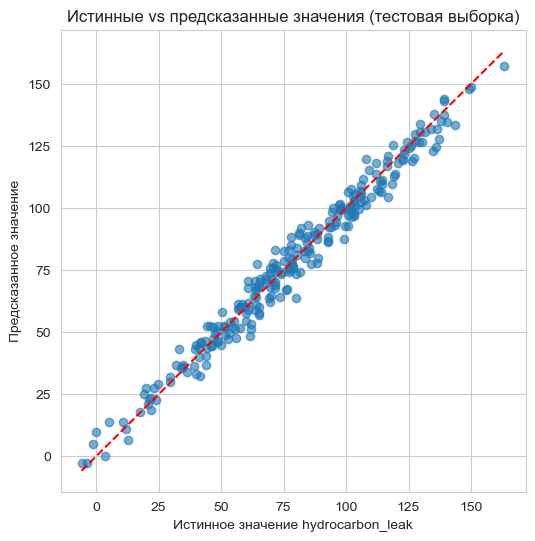

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
min_v, max_v = y_test.min(), y_test.max()
plt.plot([min_v, max_v], [min_v, max_v], 'r--')
plt.xlabel('Истинное значение hydrocarbon_leak')
plt.ylabel('Предсказанное значение')
plt.title('Истинные vs предсказанные значения (тестовая выборка)')
plt.show()

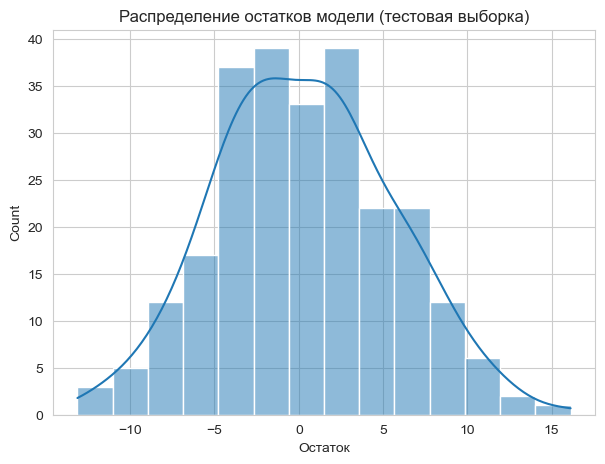

In [18]:
residuals = y_test - y_test_pred
plt.figure(figsize=(7, 5))
sns.histplot(residuals, kde=True)
plt.title('Распределение остатков модели (тестовая выборка)')
plt.xlabel('Остаток')
plt.show()

## Выводы

- Набор данных `hydrocarbon.csv` не содержит пропущенных значений и категориальных признаков.
- Все четыре признака (`temp_tank`, `temp_fuel`, `pressure_tank`, `pressure_fuel`) положительно коррелируют с целевой переменной `hydrocarbon_leak` и вносят вклад в модель.
- После нормализации данные разбиты на обучающую (75%) и тестовую (25%) выборки.
- Обученная модель линейной регрессии показывает близкие значения метрик MAE, MSE, RMSE и R² на обучающей и тестовой выборках, что говорит об отсутствии переобучения.
- Высокое значение коэффициента детерминации R² свидетельствует о хорошей объясняющей способности модели относительно количества утекающих углеводородов.